In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================
# DictaBERT NLI (clean + fixed)
# One encoder (dicta-il/dictabert) + NLI head
# Trainer subclass that correctly returns loss/logits
# Saves best model + prints final test report
# =========================

import os
os.environ["WANDB_DISABLED"] = "true"   # ✅ prevents W&B interactive prompt

import torch
import torch.nn as nn
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import f1_score, accuracy_score, classification_report


# -------------------------
# 1) Model: DictaBERT + NLI head
# -------------------------
class DictaBERTNLI(nn.Module):
    def __init__(self, model_name: str, num_labels: int = 3, dropout_p: float = 0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_p)
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,   # ✅ this fixes your error
        )
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_output))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}


# -------------------------
# 2) Custom Trainer (clean compute_loss)
# -------------------------
class NLITRainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Keep labels inside inputs for the model forward
        outputs = model(**inputs)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


# -------------------------
# 3) Load data
# -------------------------
data_files = {
    "train": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/train.jsonl",
    "validation": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/val.jsonl",
    "test": "/content/drive/MyDrive/nlp_pro2/data_sets/use_part/test.jsonl",
}
ds = load_dataset("json", data_files=data_files)

model_name = "dicta-il/dictabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

label_list = ["entailment", "contradiction", "neutral"]
label2id = {l: i for i, l in enumerate(label_list)}


def tokenize_nli(example):
    # Uses Hebrew translations as your input (translation1, translation2)
    tok = tokenizer(
        example["translation1"],
        example["translation2"],
        truncation=True,
        max_length=128,
    )
    tok["labels"] = label2id[example["label"]]
    return tok


# Remove original columns so Trainer sees only model inputs
ds_tok = ds.map(tokenize_nli, remove_columns=ds["train"].column_names)


# -------------------------
# 4) Model init + vocab safety
# -------------------------
model = DictaBERTNLI(model_name, num_labels=len(label_list))

# If tokenizer size differs from config vocab, resize embeddings
if len(tokenizer) != model.config.vocab_size:
    model.encoder.resize_token_embeddings(len(tokenizer))


# -------------------------
# 5) Metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
    }


# -------------------------
# 6) TrainingArguments
# -------------------------
args = TrainingArguments(
    output_dir="dictabert_nli",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",    # ✅ better than accuracy for NLI
    greater_is_better=True,

    fp16=torch.cuda.is_available(),  # ✅ safer
    logging_steps=50,

    remove_unused_columns=False,     # ✅ keep inputs as-is
    report_to="none",                # ✅ no W&B
)


# -------------------------
# 7) Trainer
# -------------------------
trainer = NLITRainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer),
)

trainer.train()


# -------------------------
# 8) Final test evaluation + report
# -------------------------
print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_preds = np.argmax(test_logits, axis=-1)

print(classification_report(ds_tok["test"]["labels"], test_preds, target_names=label_list))

# Optional: confusion matrix
try:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(ds_tok["test"]["labels"], test_preds)
    print("\nConfusion matrix (rows=true, cols=pred) label order:", label_list)
    print(cm)
except Exception as e:
    print("Could not print confusion matrix:", e)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dicta-il/dictabert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.589000,0.548135,0.783051,0.782671
2,0.445300,0.585608,0.789164,0.788859
3,0.269000,0.775812,0.783424,0.784114
4,0.142700,1.016050,0.782911,0.782509
5,0.082400,1.225476,0.785898,0.785903



FINAL TEST RESULTS:


               precision    recall  f1-score   support

   entailment       0.77      0.85      0.80      7211
contradiction       0.83      0.78      0.80      7114
      neutral       0.76      0.74      0.75      7104

     accuracy                           0.79     21429
    macro avg       0.79      0.79      0.79     21429
 weighted avg       0.79      0.79      0.79     21429


Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[6096  410  705]
 [ 678 5520  916]
 [1164  713 5227]]


In [6]:
trainer.save_model("/content/drive/MyDrive/nlp_pro2/saved/dictaBERT_nli_full_best_early_stopping")
tokenizer.save_pretrained("/content/drive/MyDrive/nlp_pro2/saved/dictaBERT_nli_full_best_early_stopping")
print('saving the modal!')

saving the modal!


In [7]:
print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_labels = test_out.label_ids
test_preds = np.argmax(test_logits, axis=-1)


FINAL TEST RESULTS:


In [8]:
print(classification_report(test_labels, test_preds, target_names=label_list, digits=4))
print("Confusion matrix (rows=true, cols=pred) label order:", label_list)
print(confusion_matrix(test_labels, test_preds))

               precision    recall  f1-score   support

   entailment     0.7680    0.8454    0.8048      7211
contradiction     0.8309    0.7759    0.8025      7114
      neutral     0.7633    0.7358    0.7493      7104

     accuracy                         0.7860     21429
    macro avg     0.7874    0.7857    0.7855     21429
 weighted avg     0.7873    0.7860    0.7856     21429

Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[6096  410  705]
 [ 678 5520  916]
 [1164  713 5227]]


In [9]:
# finding fp/fn per label
import numpy as np

labels = ["entailment","contradiction","neutral"]
for i, name in enumerate(labels):
    fp = np.sum((test_preds == i) & (test_labels != i))
    fn = np.sum((test_preds != i) & (test_labels == i))
    tp = np.sum((test_preds == i) & (test_labels == i))
    tn = np.sum((test_preds != i) & (test_labels != i))
    print(f"{name:13s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")

entailment    TP=6096 FP=1842 FN=1115 TN=12376
contradiction TP=5520 FP=1123 FN=1594 TN=13192
neutral       TP=5227 FP=1621 FN=1877 TN=12704


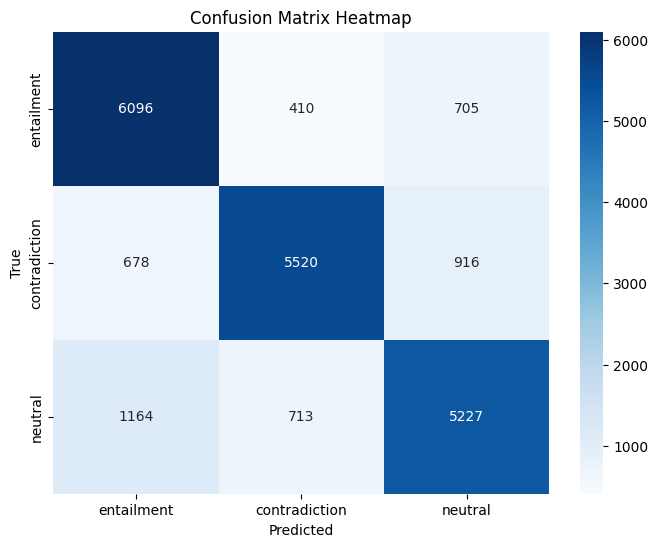

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# יצירת Heatmap למטריצת הבלבול
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [11]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# One-vs-Rest ROC AUC
auc_macro_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="weighted")

print("ROC-AUC macro (OvR):", auc_macro_ovr)
print("ROC-AUC weighted (OvR):", auc_weighted_ovr)

ROC-AUC macro (OvR): 0.9226610138515956
ROC-AUC weighted (OvR): 0.9227193563560839


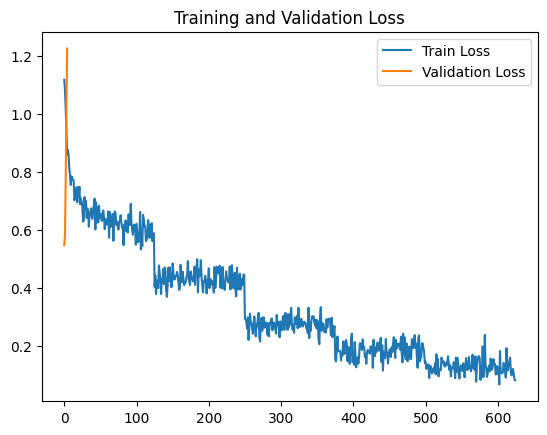

In [12]:
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

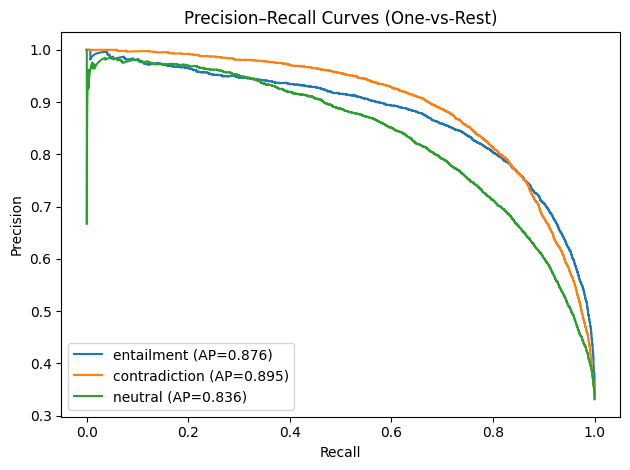

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true_bin = label_binarize(test_labels, classes=[0,1,2])  # shape (N,3)

plt.figure()
for i, name in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

inv_id2label = {0:"entailment", 1:"contradiction", 2:"neutral"}

rows = []
for i in range(len(test_labels)):
    true_id = int(test_labels[i])
    pred_id = int(test_preds[i])
    if true_id != pred_id:
        rows.append({
            "i": i,
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": inv_id2label[true_id],
            "pred": inv_id2label[pred_id],
            "pred_conf": float(probs[i, pred_id]),
            "true_conf": float(probs[i, true_id]),
            "margin": float(probs[i, pred_id] - probs[i, true_id]),
        })

err_df = pd.DataFrame(rows)
print("Total errors:", len(err_df))

Total errors: 4586


In [15]:
print("Total errors:", len(err_df))
err_df.head(3)

Total errors: 4586


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
0,0,fiction,מזל בשביל דרו שלא היו עדים נוספים עכשיו; הדמיו...,לדרו היתה תקופה של מזל רע כאשר היו לפחות תריסר...,contradiction,neutral,0.518629,0.404995,0.113634
1,1,fiction,"אבל שפטתי שחשוב לא לבזבז זמן."" וכמה שיותר בתמצ...",הוא סיפר סיפור ארוך מאוד על החוויות האחרונות שלו.,contradiction,entailment,0.577320,0.107894,0.469426
2,4,travel,"ב-1967 פננג נפגעה ממהומות רציניות, שהדגישו את ...",פננג היא עיר גדולה ופורחת ביבשת סין.,neutral,contradiction,0.536489,0.422743,0.113746


In [16]:
target = "neutral"
target_id = labels.index(target)

pred_neutral_idx = np.where(test_preds == target_id)[0]
avg_conf_pred_neutral = probs[pred_neutral_idx, target_id].mean()
print("Avg confidence when predicting neutral:", avg_conf_pred_neutral)

true_neutral_idx = np.where(test_labels == target_id)[0]
avg_conf_true_neutral = probs[true_neutral_idx, target_id].mean()
print("Avg confidence on TRUE neutral examples:", avg_conf_true_neutral)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]
avg_conf_fp = probs[fp_idx, target_id].mean() if len(fp_idx) else float("nan")
avg_conf_fn = probs[fn_idx, target_id].mean() if len(fn_idx) else float("nan")
print("Avg P(neutral) for FP neutral:", avg_conf_fp)
print("Avg P(neutral) for FN neutral:", avg_conf_fn)

avg_wrong_conf_fn = probs[fn_idx, test_preds[fn_idx]].mean() if len(fn_idx) else float("nan")
print("Avg confidence in the WRONG predicted label (on FN neutral):", avg_wrong_conf_fn)

Avg confidence when predicting neutral: 0.85282314
Avg confidence on TRUE neutral examples: 0.700215
Avg P(neutral) for FP neutral: 0.73973346
Avg P(neutral) for FN neutral: 0.17757173
Avg confidence in the WRONG predicted label (on FN neutral): 0.7677627


# option 1

In [17]:
# option 2
# to check which confusion happens the most:
import pandas as pd

# err_df must have columns: true, pred, pred_conf, genre, t1, t2
mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(mistake_counts.to_string(index=False))

         true          pred  count
      neutral    entailment   1164
contradiction       neutral    916
      neutral contradiction    713
   entailment       neutral    705
contradiction    entailment    678
   entailment contradiction    410


In [18]:
import re
import pandas as pd
import numpy as np

# err_df should already contain: t1,t2,true,pred,genre,pred_conf,margin
# If not, build it as we did earlier.

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|שנה|שנת|חודש|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")
NUM_RE  = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
PRON_RE = re.compile(r"\b(הוא|היא|הם|הן|אותו|אותה|להם|להן|שלו|שלה|שלהם|שלהן)\b")

def tokenize_set(s):
    # Hebrew-only “word” tokens
    return set(re.findall(r"[\u0590-\u05FF]{2,}", s))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def detect_patterns(t1, t2, pred_conf=None, margin=None):
    tags = []

    # Negation flip: negation present in exactly one of the sentences
    n1 = bool(NEG_RE.search(t1))
    n2 = bool(NEG_RE.search(t2))
    if n1 ^ n2:
        tags.append("Negation flip")

    # Temporal
    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("Temporal reasoning")

    # Numbers / quantifiers
    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("Quantifiers / numbers")

    # Coreference / pronouns
    if PRON_RE.search(t1) or PRON_RE.search(t2):
        tags.append("Coreference / pronouns")

    # Lexical overlap trap: lots of shared words (tends to confuse neutral vs entailment)
    A = tokenize_set(t1)
    B = tokenize_set(t2)
    overlap = jaccard(A, B)
    if overlap >= 0.35:   # tune threshold if needed
        tags.append("Lexical overlap trap")

    # Ambiguity: model not confident (or small margin)
    if pred_conf is not None and pred_conf < 0.45:
        tags.append("Ambiguity")
    if margin is not None and abs(margin) < 0.10:
        if "Ambiguity" not in tags:
            tags.append("Ambiguity")

    return tags

# Apply to err_df
err_df = err_df.copy()
err_df["tags"] = err_df.apply(
    lambda r: detect_patterns(r["t1"], r["t2"], r.get("pred_conf"), r.get("margin")),
    axis=1
)

# Explode into one tag per row for analysis
exploded = err_df.explode("tags")
tag_counts = exploded["tags"].value_counts(dropna=True)
print(tag_counts)


tags
Coreference / pronouns    1867
Quantifiers / numbers     1120
Negation flip              973
Ambiguity                  415
Temporal reasoning         285
Lexical overlap trap       284
Name: count, dtype: int64


In [19]:
# 1. הגדרת רשימת זוגות הטעויות לפי הסדר שציינתם
error_pairs = [
    ('contradiction', 'neutral'),
    ('neutral', 'entailment'),
    ('entailment', 'neutral'),
    ('contradiction', 'entailment'),
    ('neutral', 'contradiction'),
    ('entailment', 'contradiction')
]

print("ניתוח התגיות המובילות לכל סוג טעות:")
print("="*50)

for t, p in error_pairs:
    # סינון ה-exploded dataframe עבור זוג תוויות ספציפי
    subset = exploded[(exploded['true'] == t) & (exploded['pred'] == p)]

    if not subset.empty:
        # ספירת התגיות בתוך הקבוצה הזו
        tag_dist = subset['tags'].value_counts()
        top_tag = tag_dist.idxmax()
        top_count = tag_dist.max()

        print(f"טעות מסוג: {t} -> {p}")
        print(f"  הסיבה (Tag) המובילה: {top_tag}")
        print(f"  כמות מקרים: {top_count}")
        print(f"  פירוט נוסף: {tag_dist.head(2).to_dict()}") # מראה את שתי התגיות המובילות
        print("-" * 30)

ניתוח התגיות המובילות לכל סוג טעות:
טעות מסוג: contradiction -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 434
  פירוט נוסף: {'Coreference / pronouns': 434, 'Quantifiers / numbers': 254}
------------------------------
טעות מסוג: neutral -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 452
  פירוט נוסף: {'Coreference / pronouns': 452, 'Quantifiers / numbers': 230}
------------------------------
טעות מסוג: entailment -> neutral
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 309
  פירוט נוסף: {'Coreference / pronouns': 309, 'Quantifiers / numbers': 167}
------------------------------
טעות מסוג: contradiction -> entailment
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 258
  פירוט נוסף: {'Coreference / pronouns': 258, 'Quantifiers / numbers': 162}
------------------------------
טעות מסוג: neutral -> contradiction
  הסיבה (Tag) המובילה: Coreference / pronouns
  כמות מקרים: 254
  פירוט נוסף: {'Coreference / pronouns'

In [20]:
top_conf = err_df.sort_values("pred_conf", ascending=False).head(30)
top_conf[["genre","true","pred","pred_conf","margin"]].head(10)

,genre,true,pred,pred_conf,margin
1297,fiction,contradiction,neutral,0.997604,0.996391
2473,government,contradiction,neutral,0.997146,0.995386
2354,travel,contradiction,neutral,0.996588,0.994672
3855,letters,contradiction,neutral,0.996468,0.994244
1291,travel,contradiction,neutral,0.995505,0.992634
1346,government,contradiction,neutral,0.995087,0.993002
3610,slate,contradiction,neutral,0.994924,0.991634
4134,travel,neutral,contradiction,0.994888,0.990818
1522,government,contradiction,neutral,0.994569,0.991835
1335,government,contradiction,neutral,0.994529,0.990433
